In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from dataset import *

# Helper functions and variable definitions

In [2]:
activations = ["relu", "elu", "gelu", "leaky-relu", "quadratic"]
data_types = ["fashion_mnist", "cifar10_shallow"]

In [3]:
activations_save = {
    "relu": "ReLU",
    "elu": "ELU",
    "gelu": "GELU",
    "leaky-relu": "Leaky ReLU",
    "quadratic": "Quadratic"
}

data_types_save = {
    "fashion_mnist": "Fashion MNIST",
    "cifar10_shallow": "CIFAR-10"
}

# Plot training and test accuracies vs. width

## Accuracy vs. width for different activation functions

In [4]:
widths = [32, 64, 128, 256, 512, 1024, 2048, 4096]
K = 10
num_trials = 5

parent_dir = "/scratch/qingqu_root/qingqu1/alecx/uos-lin-sep-results/"

# Load in saved results
fmnist_train_accs = np.zeros((num_trials, len(widths), len(activations)))
cifar_train_accs = np.zeros((num_trials, len(widths), len(activations)))

for k in range(num_trials):
    trial_dir = "trial_" + str(k)
    for (i, width) in enumerate(widths):
        for (j, activation) in enumerate(activations):
            results_dir =  "width_" + str(width) + "_depth_2_nonlinear_depth_1_" + str(K) + "_classes_" + activation + "_activation_seed_0"
            
            fmnist_results_dir = os.path.join(parent_dir, "fashion_mnist", results_dir)
            fmnist_best_train = torch.load(os.path.join(fmnist_results_dir, trial_dir, "best.pth"), map_location=torch.device('cpu'))
            fmnist_train_accs[k, i, j] = np.max(fmnist_best_train['train_accuracies'])
            
            cifar_results_dir = os.path.join(parent_dir, "cifar10_shallow", results_dir)
            cifar_best_train = torch.load(os.path.join(cifar_results_dir, trial_dir, "best.pth"), map_location=torch.device('cpu'))
            cifar_train_accs[k, i, j] = np.max(cifar_best_train['train_accuracies'])
            

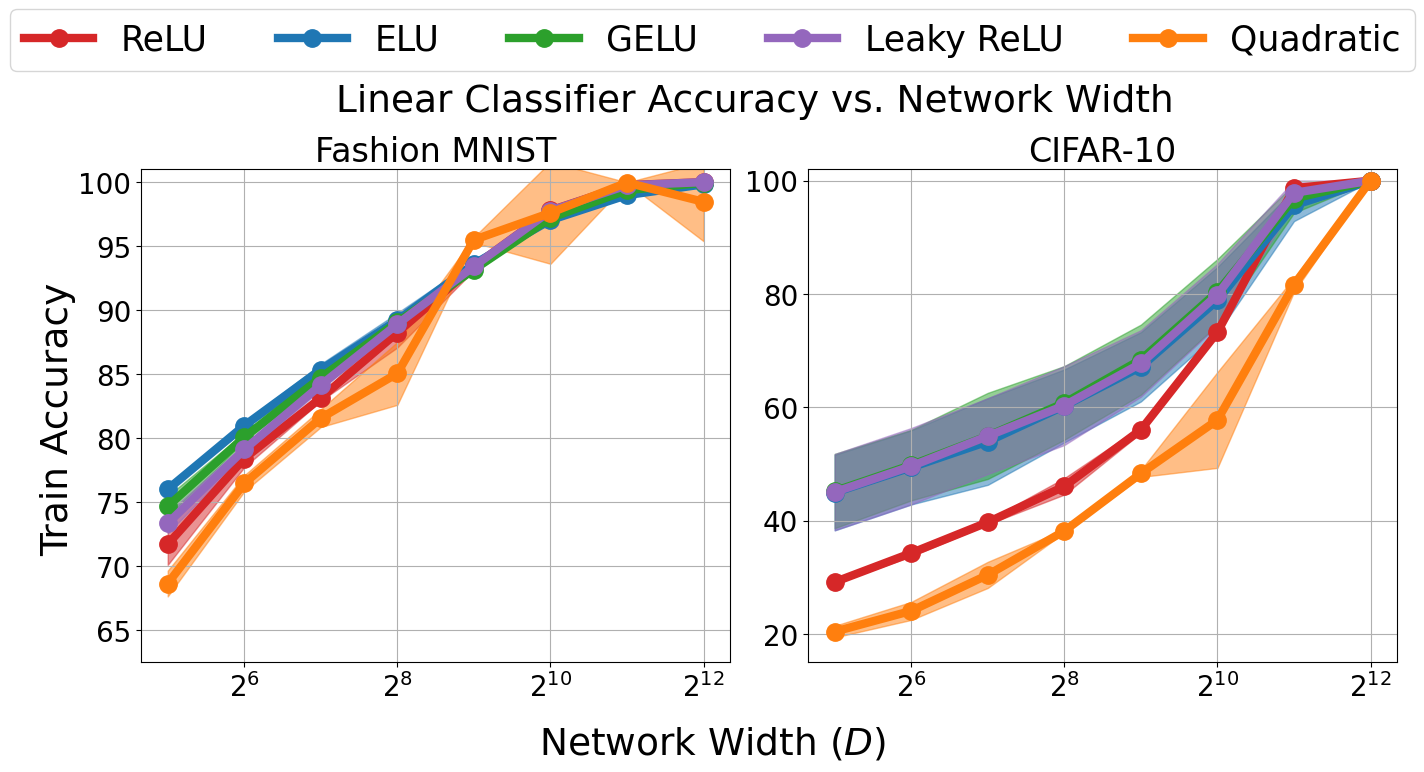

In [5]:
fmnist_mean = np.mean(fmnist_train_accs, axis=0)
fmnist_std = np.std(fmnist_train_accs, axis=0)

cifar_mean = np.mean(cifar_train_accs, axis=0)
cifar_std = np.std(cifar_train_accs, axis=0)

# Plot results
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 7))


start_idx = 1
lw = 6
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:purple', 'tab:orange'] 

# Plot Fashion MNIST
lns = []
for i in range(len(colors)):
    l_i = ax1.plot(widths, list(fmnist_mean[:, i]), color=colors[i], linewidth=lw, marker=".", markersize=25,
                  label=activations_save[activations[i]])
    ax1.fill_between(widths, list(fmnist_mean[:, i] - fmnist_std[:, i]), list(fmnist_mean[:, i] + fmnist_std[:, i]),
                    color=colors[i], alpha=0.5)
    lns += l_i

ax1.set_xscale('log', base=2)
ax1.tick_params(axis='y', labelsize=20)
ax1.tick_params(axis='x', labelsize=20)

labs = [l.get_label() for l in lns]
ax1.grid()
ax1.set_ylim(62.5, 101)
ax1.set_title('Fashion MNIST', fontsize=24)

# Plot CIFAR-10
lns = []
for i in range(len(colors)):
    l_i = ax2.plot(widths, list(cifar_mean[:, i]), color=colors[i], linewidth=lw, marker=".", markersize=25,
                  label=activations_save[activations[i]])
    ax2.fill_between(widths, list(cifar_mean[:, i] - cifar_std[:, i]), list(cifar_mean[:, i] + cifar_std[:, i]),
                    color=colors[i], alpha=0.5)
    lns += l_i

ax2.set_xscale('log', base=2)
ax2.tick_params(axis='y', labelsize=20)
ax2.tick_params(axis='x', labelsize=20)

labs = [l.get_label() for l in lns]
ax2.grid()
ax2.set_ylim(15, 102)
ax2.set_title('CIFAR-10', fontsize=24)

fig.suptitle('Linear Classifier Accuracy vs. Network Width', fontsize=27, x=0.53)
fig.supxlabel(r'Network Width ($D$)', fontsize=27)
fig.supylabel('Train Accuracy', fontsize=27)
fig.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5,1.11), ncol=len(activations), fontsize=25)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig('./figures/fashion_mnist_cifar10.pdf', bbox_inches='tight')
plt.show()